In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

engine = create_engine(
    "mysql+pymysql://root:@localhost:3309/ecommerce_analytics1"
)

print("Database Connected Successfully!")



Database Connected Successfully!


In [2]:
# KPI 1: Total Revenue
# Cell 3
query = """
SELECT ROUND(SUM(payment_value),2) AS total_revenue
FROM payments;
"""

revenue = pd.read_sql(query, engine)

revenue
# Cell 4
print(f"Total Revenue: ₹ {revenue.iloc[0,0]:,.2f}")

Total Revenue: ₹ 16,008,872.12


In [11]:
query = """
SELECT
    LEFT(order_purchase_timestamp,7) AS month,
    COUNT(*) AS total_orders
FROM orders
GROUP BY month
ORDER BY month;
"""

monthly_orders = pd.read_sql(query, engine)

monthly_orders.head()

,month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


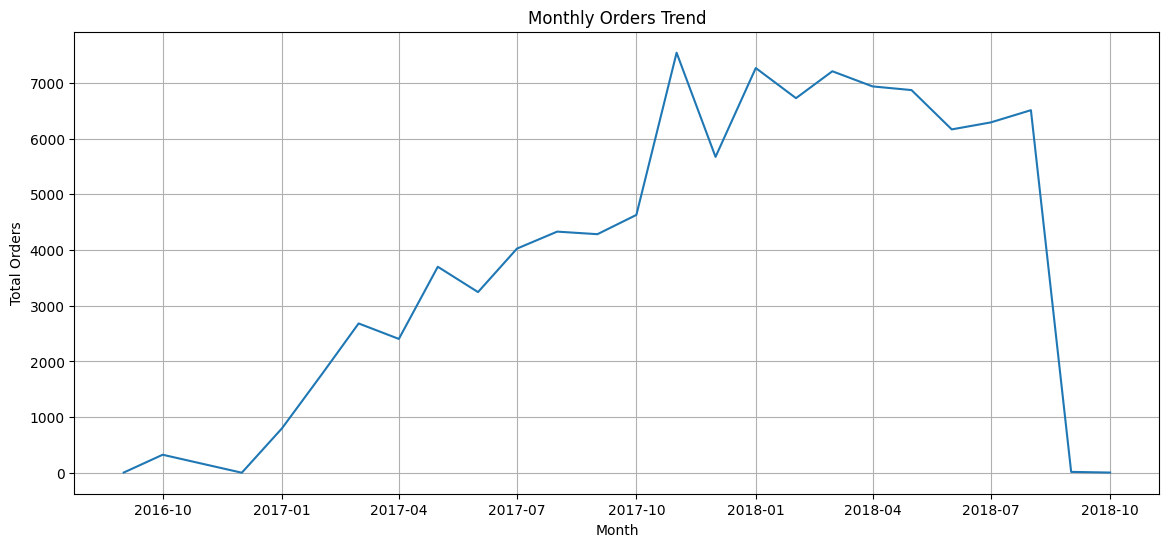

In [12]:
monthly_orders['month'] = pd.to_datetime(monthly_orders['month'])

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders['month'],
    monthly_orders['total_orders']
)

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.grid(True)

plt.show()

In [3]:
#KPI 2: Average Order Value

query = """
SELECT ROUND(AVG(payment_value),2) AS avg_order_value
FROM payments;
"""

aov = pd.read_sql(query, engine)

aov

,avg_order_value
0,154.1


In [17]:
#Revenue by Payment Type

query = """
SELECT
    payment_type,
    ROUND(SUM(payment_value),2) AS revenue
FROM payments
GROUP BY payment_type
ORDER BY revenue DESC;
"""

payment_revenue = pd.read_sql(query, engine)

payment_revenue

,payment_type,revenue
0,credit_card,12542084.19
1,boleto,2869361.27
2,voucher,379436.87
3,debit_card,217989.79
4,not_defined,0.00


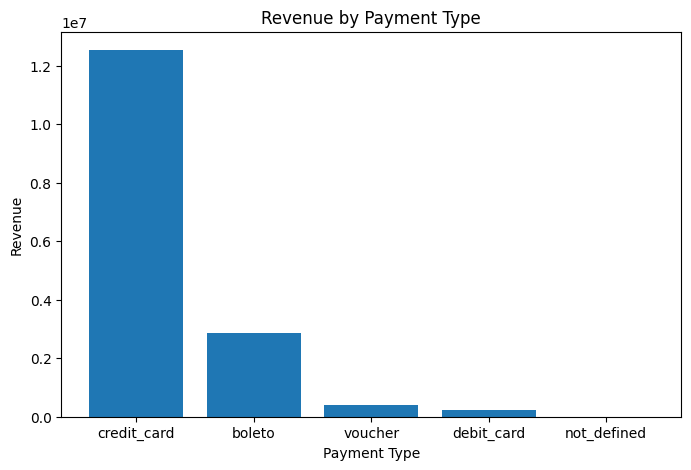

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    payment_revenue['payment_type'],
    payment_revenue['revenue']
)

plt.title("Revenue by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Revenue")

plt.show()

In [19]:
# order by status

query = """
SELECT
    order_status,
    COUNT(*) AS total_orders
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC;
"""

status_df = pd.read_sql(query, engine)

status_df

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


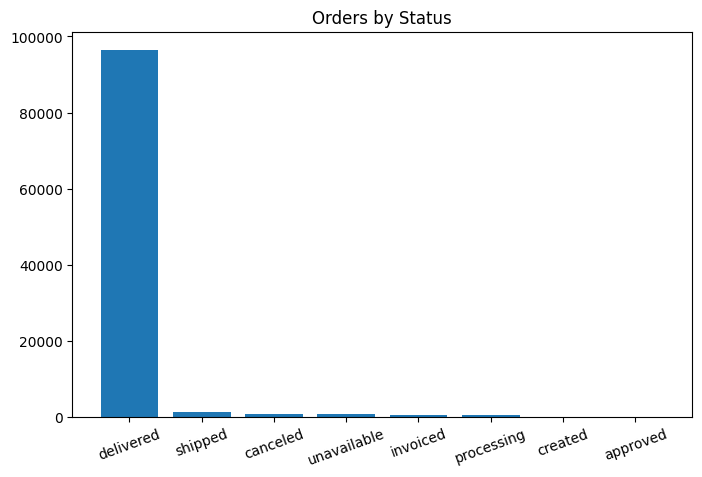

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    status_df['order_status'],
    status_df['total_orders']
)

plt.xticks(rotation=20)

plt.title("Orders by Status")

plt.show()

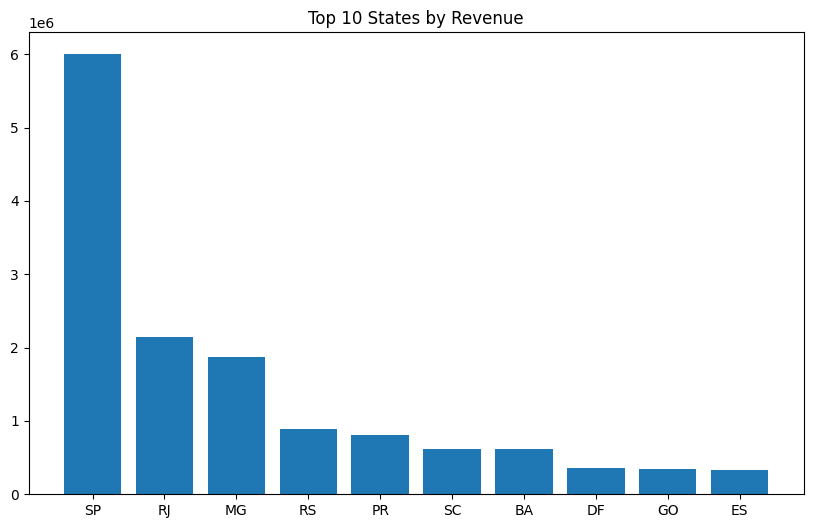

In [27]:
#Revenue by State

query = """
SELECT
    c.customer_state,
    ROUND(SUM(p.payment_value),2) AS revenue
FROM customers c
JOIN orders o
ON c.customer_id=o.customer_id
JOIN payments p
ON o.order_id=p.order_id
GROUP BY c.customer_state
ORDER BY revenue DESC;
"""

state_revenue = pd.read_sql(query, engine)

#state_revenue.head()

top_states = state_revenue.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_states['customer_state'],
    top_states['revenue']
)

plt.title("Top 10 States by Revenue")

plt.show()